<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/dragon_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Royal Draconic Conservatory - Regression**

# **Importing Libraries**

In [1]:
!pip -q install plotly scikit-learn tabulate pandas

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

In [3]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/dragon_data.csv"
df = pd.read_csv(url)
df.head()

,SPC,AGE,MASS,WSP,HID,SPD,FHO
0,Wyvern,16,1304,4.0,4.83,4800,611
1,Dragon,2726,3693174,52.0,4.82,114400,1960
2,Dragon,377,154201,19.4,4.61,42680,1123
3,Hydra,169,40146,13.0,2.65,7800,706
4,Dragon,1571,1549315,39.6,1.49,87120,1441


In [4]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "FHO", "description": "The target variable — Flame Heat Output (in degrees Celsius)."},
    {"variable": "WSP", "description": "Wingspan (in meters)."},
    {"variable": "MASS", "description": "Mass (in metric tons)."},
    {"variable": "AGE", "description": "Age (in years)."},
    {"variable": "SPD", "description": "Sustained flight speed (in km/h)."},
    {"variable": "HID", "description": "Hide thickness (in cm)."},
    {"variable": "SPC", "description": "Species (e.g. Dragon, Wyvern or Hyrdra)."},

]

# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+------------+---------------------------------------------------------------+
|    | variable   | description                                                   |
+====+============+===============================================================+
|  0 | FHO        | The target variable — Flame Heat Output (in degrees Celsius). |
+----+------------+---------------------------------------------------------------+
|  1 | WSP        | Wingspan (in meters).                                         |
+----+------------+---------------------------------------------------------------+
|  2 | MASS       | Mass (in metric tons).                                        |
+----+------------+---------------------------------------------------------------+
|  3 | AGE        | Age (in years).                                               |
+----+------------+---------------------------------------------------------------+
|  4 | SPD        | Sustained flight speed (in km/h).                       

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,500.0,461.4740,643.250280,-481.00,105.5000,240.00,585.00,5407.0
MASS,500.0,309248.6900,751723.845284,17.00,19392.2500,79675.00,282531.50,9729833.0
WSP,500.0,18.1994,11.503709,1.00,10.4000,15.60,24.20,73.6
HID,500.0,2.9993,1.167213,1.01,1.9175,2.94,4.04,5.0
SPD,500.0,24157.1200,26568.849928,600.00,7665.0000,13890.00,29550.00,161920.0
FHO,500.0,894.2440,350.478483,100.00,664.0000,871.50,1109.50,2358.0


#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [6]:
# Split into train and test (70/30)
train_df, test_df = train_test_split(df,test_size = 0.2,
    random_state = 42)

# **1. Single Variable Regression**



## WSP

In [7]:
# Training Model
X_train = train_df[["WSP"]]
y_train = train_df["FHO"]

X_test = test_df[["WSP"]]
y_test = test_df["FHO"]

wsp_model = LinearRegression()
wsp_model.fit(X_train, y_train)

LinearRegression()

### Model Evaluation

In [8]:
# Training R-squared
train_r2_wsp = wsp_model.score(X_train, y_train)
print("Training - R-Squared:", train_r2_wsp)

Training - R-Squared: 0.494672105612152


In [9]:
# Testing Performant
y_pred_wsp = wsp_model.predict(X_test)
test_r2_wsp = r2_score(y_test, y_pred_wsp)
rmse_wsp = np.sqrt(mean_squared_error(y_test, y_pred_wsp))

print("Test R-squared:", test_r2_wsp)
print("Test RMSE:", rmse_wsp)

Test R-squared: 0.5416536400319366
Test RMSE: 240.14499042193296


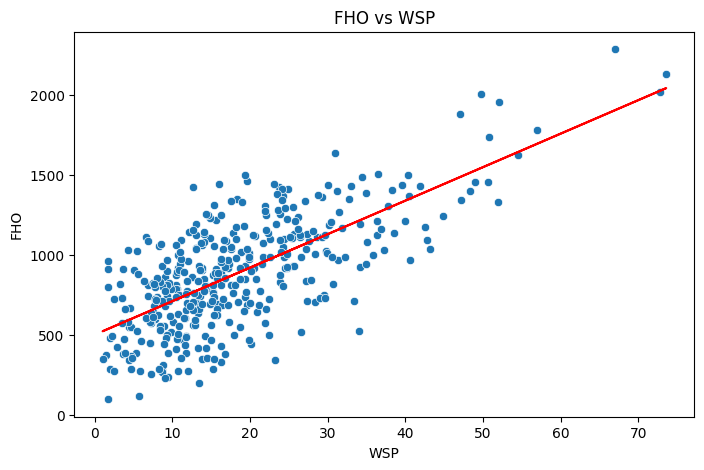

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(x = train_df["WSP"], y = train_df["FHO"])

plt.plot(
    train_df["WSP"],
    wsp_model.predict(X_train),
    color = "red"
)

plt.xlabel("WSP")
plt.ylabel("FHO")
plt.title("FHO vs WSP")

plt.show()

## MASS

In [11]:
# Training Model
X_train = train_df[["MASS"]]
X_test = test_df[["MASS"]]

mass_model = LinearRegression()
mass_model.fit(X_train, y_train)

LinearRegression()

### Model Evaluation

In [12]:
# Training R squared
train_r2_mass = mass_model.score(X_train, y_train)
y_pred_mass = mass_model.predict(X_test)
print("Training R-squared:", train_r2_mass)

Training R-squared: 0.3316798226981259


In [13]:
# Testing R Squared
test_r2_mass = r2_score(y_test, y_pred_mass)
rmse_mass = np.sqrt(mean_squared_error(y_test, y_pred_mass))

print("Test R-squared:", test_r2_mass)
print("Test RMSE:", rmse_mass)

Test R-squared: 0.36006158360421603
Test RMSE: 283.7564415317687


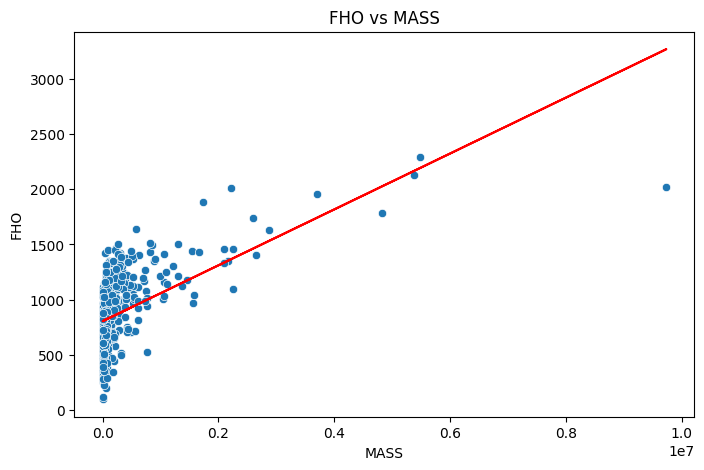

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x = train_df["MASS"], y = train_df["FHO"])

plt.plot(
    train_df["MASS"],
    mass_model.predict(X_train),
    color="red"
)

plt.xlabel("MASS")
plt.ylabel("FHO")
plt.title("FHO vs MASS")

plt.show()

## AGE

In [15]:
X_train = train_df[["AGE"]]
X_test = test_df[["AGE"]]

age_model = LinearRegression()
age_model.fit(X_train, y_train)

LinearRegression()

### Model Evaluation

In [16]:
# Training R Squared
train_r2_age = age_model.score(X_train, y_train)
print("Training R - Squared:", train_r2_age)

Training R - Squared: 0.4335896587740389


In [17]:
# Test Results
y_pred_age = age_model.predict(X_test)

test_r2_age = r2_score(y_test, y_pred_age)
rmse_age = np.sqrt(mean_squared_error(y_test, y_pred_age))

print("Test R-Squared:", test_r2_age)
print("Test RMSE:", rmse_age)

Test R-Squared: 0.4786814734073791
Test RMSE: 256.1109916057116


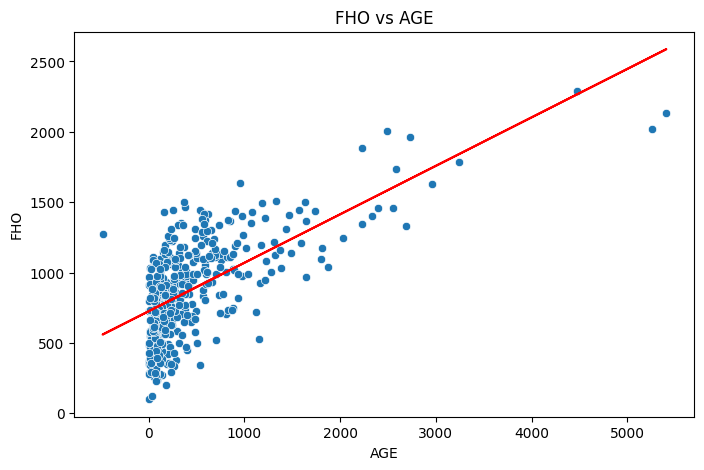

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(x = train_df["AGE"], y = train_df["FHO"])

plt.plot(
    train_df["AGE"],
    age_model.predict(X_train),
    color="red"
)

plt.xlabel("AGE")
plt.ylabel("FHO")
plt.title("FHO vs AGE")

plt.show()

## SPC

In [19]:
# Encode Model
encoder = OneHotEncoder(drop = "first", sparse_output = False)

# Train Model
X_train_spc = encoder.fit_transform(train_df[["SPC"]])
X_test_spc = encoder.transform(test_df[["SPC"]])

spc_model = LinearRegression()
spc_model.fit(X_train_spc, y_train)

LinearRegression()

### Model Evaluation

In [20]:
# Training R-Squared
train_r2_spc = spc_model.score(X_train_spc, y_train)

print("Training R-Squared:", train_r2_spc)

Training R-Squared: 0.17278125701423763


In [21]:
# Test R-Squared
y_pred_spc = spc_model.predict(X_test_spc)

test_r2_spc = r2_score(y_test, y_pred_spc)
rmse_spc = np.sqrt(mean_squared_error(y_test, y_pred_spc))

print("Test R-Squared:", test_r2_spc)
print("Test RMSE:", rmse_spc)

Test R-Squared: 0.08922216627572888
Test RMSE: 338.5188557604722


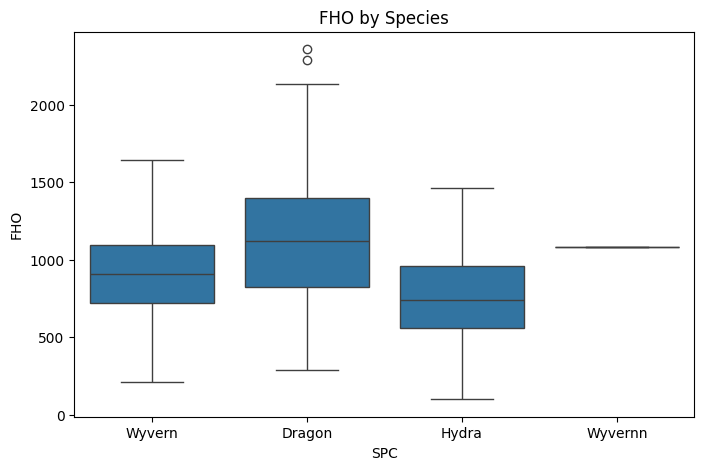

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x = "SPC", y = "FHO", data = df)

plt.title("FHO by Species")
plt.show()

## Models Comparison

In [23]:
# Comparing Models
results = pd.DataFrame({
    "Model": ["WSP", "MASS", "AGE", "SPC"],
    "Training R-Squared": [
        train_r2_wsp,
        train_r2_mass,
        train_r2_age,
        train_r2_spc
    ],
    "Test R-Squared": [
        test_r2_wsp,
        test_r2_mass,
        test_r2_age,
        test_r2_spc
    ],
    "Test RMSE": [
        rmse_wsp,
        rmse_mass,
        rmse_age,
        rmse_spc
    ]
})

# Display the DataFrame
var_desc_final = results.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+---------+----------------------+------------------+-------------+
|    | Model   |   Training R-Squared |   Test R-Squared |   Test RMSE |
+====+=========+======================+==================+=============+
|  0 | WSP     |             0.494672 |        0.541654  |     240.145 |
+----+---------+----------------------+------------------+-------------+
|  1 | MASS    |             0.33168  |        0.360062  |     283.756 |
+----+---------+----------------------+------------------+-------------+
|  2 | AGE     |             0.43359  |        0.478681  |     256.111 |
+----+---------+----------------------+------------------+-------------+
|  3 | SPC     |             0.172781 |        0.0892222 |     338.519 |
+----+---------+----------------------+------------------+-------------+


- Among the single-variable regression models, Wingspan (WSP) achieved the strongest predictive performance with a test R-squared of approximately 0.54 and the lowest RMSE. This means that larger dragons tend to produce substantially hotter flames.

# **2. Multiple Variable Regression**



### Train Models

In [24]:
models = {

    "WSP & AGE": ["WSP", "AGE"],

    "WSP & AGE & MASS":
        ["WSP", "AGE", "MASS"],

    "WSP & AGE & MASS & SPD":
        ["WSP", "AGE", "MASS", "SPD"],

    "WSP & AGE & MASS & SPD & HID":
        ["WSP", "AGE", "MASS", "SPD", "HID"],

    "All Variables":
        ["WSP", "AGE", "MASS", "SPD", "HID", "SPC"]
}


In [25]:
def evaluate_model(features):

    X_train = train_df[features]
    X_test = test_df[features]

    numeric_features = [
        col for col in features if col != "SPC"
    ]

    categorical_features = [
        col for col in features if col == "SPC"
    ]

    preprocessor = ColumnTransformer(
        transformers = [
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(drop = "first"), categorical_features)
        ],
        remainder = "drop"
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    return train_r2, test_r2, test_rmse


In [31]:
# Train and Evaluate Model
results = []

for name, features in models.items():

    train_r2, test_r2, rmse = evaluate_model(features)

    results.append({
        "Model": name,
        "Train R-Squared": train_r2,
        "Test R-Squared": test_r2,
        "Test RMSE": rmse
    })

results_df = pd.DataFrame(results)

final = results_df.sort_values(
    by = "Test R-Squared",
    ascending=False
)
print(final)

                          Model  Train R-Squared  Test R-Squared   Test RMSE
2        WSP & AGE & MASS & SPD         0.499411        0.548204  238.422942
3  WSP & AGE & MASS & SPD & HID         0.499850        0.544409  239.421970
1              WSP & AGE & MASS         0.497052        0.543122  239.760114
0                     WSP & AGE         0.494713        0.541785  240.110640
4                 All Variables         0.503316        0.540176  240.531668


# **3. Model Comparison**

In [ ]:
# Display the DataFrame
var_desc_final = final.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

Multiple regression models were constructed using different subsets of dragon characteristics to predict flame heat output (FHO).

Although adding additional predictors produced small improvements in predictive performance, the gains were marginal. The best-performing model, containing WSP, AGE, MASS, and SPD, achieved a test R-Squared of approximately 0.55.

The limited improvement from additional variables indicates possible multicollinearity among predictors, particularly between physical size-related variables such as wingspan and mass.

Including SPC and HID did not improve performance and slightly reduced test accuracy, suggesting that these variables provide little independent predictive information.

Overall, the WSP + AGE model may be preferred because it achieves nearly identical predictive performance while remaining substantially simpler and easier to interpret.

# **4. Interpretability**

In [32]:
best_features = ["WSP", "AGE", "MASS", "SPD"]

X = df[best_features]
y = df["FHO"]

model = LinearRegression()
model.fit(X, y)

coefficients = pd.DataFrame({
    "Feature": best_features,
    "Coefficient": model.coef_
})

print(coefficients)

  Feature  Coefficient
0     WSP    22.544938
1     AGE    -0.165600
2    MASS     0.000080
3     SPD     0.001769


The regression coefficients were generally biologically plausible. Wingspan (WSP) had by far the strongest positive effect on flame heat output, with each additional meter of wingspan increasing predicted FHO by approximately 22.5°C. This suggests that overall dragon size is the primary driver of flame intensity, likely due to increased lung capacity, airflow generation, and flame-producing organ size.

Sustained flight speed (SPD) also showed a small positive relationship with FHO, possibly reflecting improved oxygen circulation and respiratory efficiency in faster dragons. Mass (MASS) contributed almost no independent predictive power once wingspan was included, suggesting that body mass is largely redundant with overall size measurements.

A surprising result was the slight negative coefficient for age (AGE). While older dragons might be expected to produce hotter flames, the model suggests that among dragons of similar size, older individuals may experience minor declines in flame efficiency, potentially due to aging-related physiological deterioration.

Overall, the results indicate that flame heat output depends primarily on dragon size rather than age, speed, or body mass alone.

# **5. Model Evaluation**